# Phase 1 — EDA · Dataset IBM Telco v11.1.3 (6 fichiers)

**Source** : Kaggle `ylchang/telco-customer-churn-1113` (IBM Cognos Analytics samples)

**Différences vs version Kaggle de base** :
- ~50 colonnes (vs 33) après merge des 6 fichiers
- Nouvelles features riches : `Number of Referrals`, `Offer`, `Internet Type`, `Avg Monthly GB Download`, `Total Refunds`, `Age` (continu), `Married`, `Population`...
- Nouveaux leakers à auditer : `Customer Status`, `Churn Category`

**Objectifs**
1. Profiler le dataset après merge multi-fichiers.
2. Construire la cible NPS et tester la sensibilité au mapping.
3. **Audit quantitatif des fuites** — confirmer LEAKY_FEATURES.
4. Explorer les distributions des features par classe NPS.
5. Sauvegarder les figures clés dans `reports/figures/` pour le rapport final.

## 0. Setup

In [1]:
# Allow imports from project root when running notebook from notebooks/
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import (
    DATA_INTERIM, FIGURES_DIR, LEAKY_FEATURES,
    SATISFACTION_TO_NPS_BASELINE, NPS_CLASSES,
)
from src.data.load import load_raw_telco
from src.data.audit_leaks import audit as run_leakage_audit

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

NPS_PALETTE = {"Detractor": "#d62728", "Passive": "#ff7f0e", "Promoter": "#2ca02c"}
print("Setup OK")

Setup OK


## 1. Chargement & merge multi-fichiers

In [3]:
df = load_raw_telco()
print(f"\n→ Shape final: {df.shape[0]:,} rows × {df.shape[1]} columns")

Scanning C:\Users\LOG\OneDrive - SUPCOM\Bureau\Challenge NPS Dr FOFANA\nps-prediction\data\raw...
  Multi-file layout detected (6 files)
    · Telco_customer_churn.xlsx:  7043 rows × 33 cols
    · Telco_customer_churn_demographics.xlsx:  7043 rows ×  9 cols
    · Telco_customer_churn_location.xlsx:  7043 rows ×  9 cols
    · Telco_customer_churn_population.xlsx:  1671 rows ×  3 cols
    · Telco_customer_churn_services.xlsx:  7043 rows × 30 cols
    · Telco_customer_churn_status.xlsx:  7043 rows × 11 cols

  Base file: Telco_customer_churn (7043 rows × 33 cols)
    + Telco_customer_churn_services: +13 new cols → 7043 × 46
    + Telco_customer_churn_status: +3 new cols → 7043 × 49
    + Telco_customer_churn_demographics: +4 new cols → 7043 × 53
    - Telco_customer_churn_location: no new columns, skipped
    + Telco_customer_churn_population: joined on Zip Code, +2 cols

  ✓ Final dataset: 7,043 rows × 55 columns

→ Shape final: 7,043 rows × 55 columns


In [4]:
df.head()

,Customer ID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason,Quarter,Referred a Friend,Number of Referrals,Offer,Avg Monthly Long Distance Charges,Internet Type,Avg Monthly GB Download,Streaming Music,Unlimited Data,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Category,Age,Under 30,Married,Number of Dependents,ID,Population
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer,Q3,No,0,NaN,10.47,DSL,21,No,Yes,0.0,0,20.94,129.09,1,Churned,Competitor,37,No,No,0,3,58198
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved,Q3,No,0,NaN,9.12,Fiber Optic,51,No,Yes,0.0,0,18.24,169.89,2,Churned,Other,19,Yes,No,2,5,43019
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved,Q3,No,0,NaN,12.15,Cable,26,Yes,Yes,0.0,0,97.20,917.70,3,Churned,Other,31,No,No,2,6,62784
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved,Q3,No,0,Offer C,4.89,Fiber Optic,47,Yes,Yes,0.0,0,136.92,3182.97,3,Churned,Other,23,Yes,Yes,3,9,1957
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices,Q3,No,0,NaN,44.33,Fiber Optic,11,Yes,Yes,0.0,0,2172.17,7208.47,1,Churned,Competitor,38,No,No,1,14,15140


In [5]:
# Inventaire des colonnes par type
print("--- Numeric columns ---")
print(df.select_dtypes(include=np.number).columns.tolist())
print("\n--- Object/Categorical columns ---")
print(df.select_dtypes(exclude=np.number).columns.tolist())

--- Numeric columns ---
['Count', 'Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Value', 'Churn Score', 'CLTV', 'Number of Referrals', 'Avg Monthly Long Distance Charges', 'Avg Monthly GB Download', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Satisfaction Score', 'Age', 'Number of Dependents', 'ID', 'Population']

--- Object/Categorical columns ---
['Customer ID', 'Country', 'State', 'City', 'Lat Long', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Churn Label', 'Churn Reason', 'Quarter', 'Referred a Friend', 'Offer', 'Internet Type', 'Streaming Music', 'Unlimited Data', 'Customer Status', 'Churn Category', 'Under 30', 'Married']


## 2. Qualité des données

### 2.1 Doublons et identifiants

In [6]:
id_col = "Customer ID" if "Customer ID" in df.columns else df.columns[0]
print(f"Identifier column: {id_col}")
print(f"Unique IDs: {df[id_col].nunique():,} / {len(df):,} rows")
print(f"Duplicates: {df.duplicated(id_col).sum()}")

Identifier column: Customer ID
Unique IDs: 7,043 / 7,043 rows
Duplicates: 0


### 2.2 Valeurs manquantes

In [7]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"n_missing": missing, "pct": missing_pct})
missing_df = missing_df[missing_df["n_missing"] > 0]

if missing_df.empty:
    print("No missing values 🎉")
else:
    print(f"{len(missing_df)} columns have missing values:\n")
    print(missing_df)

5 columns have missing values:

                n_missing    pct
Churn Reason         5174  73.46
Churn Category       5174  73.46
Offer                3877  55.05
Internet Type        1526  21.67
Total Charges          11   0.16


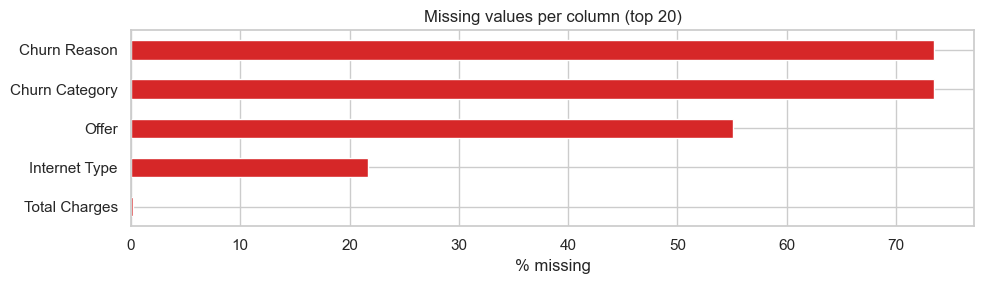


Note: 'Churn Reason' / 'Churn Category' / 'Offer' high-missing is EXPECTED:
  - Churn Reason/Category: only filled for churners → reveals Customer Status
  - Offer: NaN means no offer received


In [8]:
# Visualize missingness (top 20)
if not missing_df.empty:
    top = missing_df.head(20)
    fig, ax = plt.subplots(figsize=(10, max(3, 0.3 * len(top))))
    top["pct"].plot(kind="barh", ax=ax, color="#d62728")
    ax.set_xlabel("% missing")
    ax.set_title("Missing values per column (top 20)")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "01_missing.png")
    plt.show()
    print("\nNote: 'Churn Reason' / 'Churn Category' / 'Offer' high-missing is EXPECTED:")
    print("  - Churn Reason/Category: only filled for churners → reveals Customer Status")
    print("  - Offer: NaN means no offer received")

### 2.3 Colonnes constantes

In [9]:
constants = [(c, df[c].iloc[0]) for c in df.columns if df[c].nunique(dropna=False) <= 1]
if constants:
    print("Constant columns (will be dropped from features):")
    for c, v in constants:
        print(f"  {c:<25} = {v!r}")
else:
    print("No constant columns.")

Constant columns (will be dropped from features):
  Count                     = 1
  Country                   = 'United States'
  State                     = 'California'
  Quarter                   = 'Q3'


## 3. Cible source — `Satisfaction Score`

C'est l'unique source du label NPS. Distribution attendue : asymétrique (les répondants polarisés répondent plus).

In [10]:
sat = df["Satisfaction Score"]
print("Distribution:")
counts = sat.value_counts().sort_index()
for s, n in counts.items():
    pct = n / len(df) * 100
    print(f"  Score {s}: {n:>5,} ({pct:>5.1f}%)")
print(f"\nMean: {sat.mean():.2f}, Median: {sat.median()}, Std: {sat.std():.2f}")

Distribution:
  Score 1:   922 ( 13.1%)
  Score 2:   518 (  7.4%)
  Score 3: 2,665 ( 37.8%)
  Score 4: 1,789 ( 25.4%)
  Score 5: 1,149 ( 16.3%)

Mean: 3.24, Median: 3.0, Std: 1.20


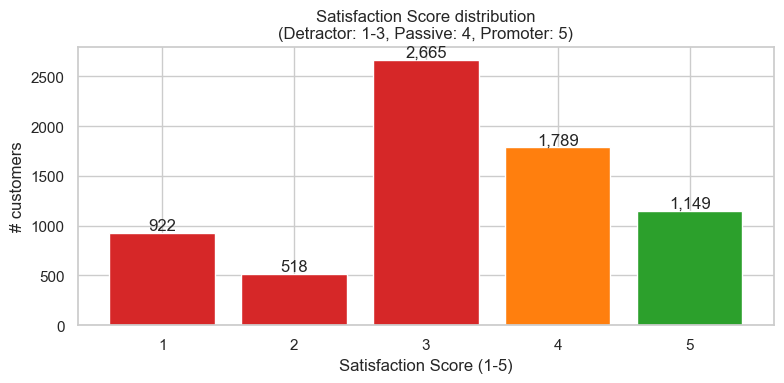

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
colors_per_score = ["#d62728", "#d62728", "#d62728", "#ff7f0e", "#2ca02c"]
bars = ax.bar(counts.index, counts.values, color=colors_per_score)
ax.set_xlabel("Satisfaction Score (1-5)")
ax.set_ylabel("# customers")
ax.set_title("Satisfaction Score distribution\n(Detractor: 1-3, Passive: 4, Promoter: 5)")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{int(bar.get_height()):,}", ha="center", va="bottom")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_satisfaction.png")
plt.show()

## 4. Cible dérivée — distribution NPS

In [12]:
df["NPS_class"] = df["Satisfaction Score"].map(SATISFACTION_TO_NPS_BASELINE)
df["NPS_class"] = pd.Categorical(df["NPS_class"], categories=NPS_CLASSES, ordered=True)

dist = df["NPS_class"].value_counts(normalize=True).reindex(NPS_CLASSES) * 100
counts_n = df["NPS_class"].value_counts().reindex(NPS_CLASSES)
print("NPS class distribution (baseline mapping):")
for cls in NPS_CLASSES:
    print(f"  {cls:<10} {counts_n[cls]:>5,} ({dist[cls]:>5.1f}%)")

# Compute the actual NPS index for reference
nps_index = dist["Promoter"] - dist["Detractor"]
print(f"\nNPS index (% Promoters − % Detractors): {nps_index:+.1f}")

NPS class distribution (baseline mapping):
  Detractor  4,105 ( 58.3%)
  Passive    1,789 ( 25.4%)
  Promoter   1,149 ( 16.3%)

NPS index (% Promoters − % Detractors): -42.0


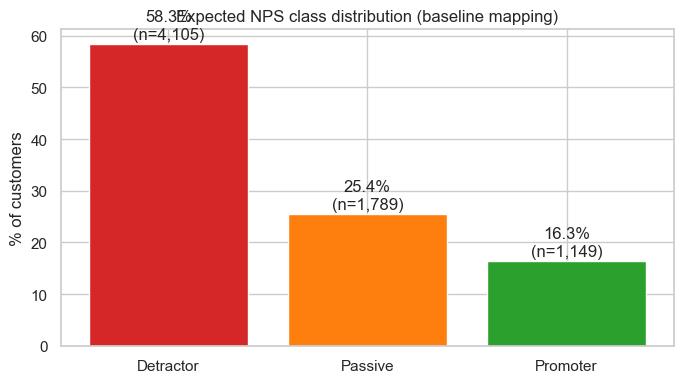

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
colors = [NPS_PALETTE[c] for c in NPS_CLASSES]
bars = ax.bar(NPS_CLASSES, dist.values, color=colors)
ax.set_ylabel("% of customers")
ax.set_title("Expected NPS class distribution (baseline mapping)")
for bar, n in zip(bars, counts_n.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{bar.get_height():.1f}%\n(n={n:,})", ha="center", va="bottom")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_nps_distribution.png")
plt.show()

### 4.1 Sensibilité au mapping

In [14]:
mappings = {
    "Strict (5→Prom, 4→Pass)": {1: "Detractor", 2: "Detractor", 3: "Detractor", 4: "Passive", 5: "Promoter"},
    "Loose (4-5→Prom)": {1: "Detractor", 2: "Detractor", 3: "Detractor", 4: "Promoter", 5: "Promoter"},
    "Conservative (1-2→Det only)": {1: "Detractor", 2: "Detractor", 3: "Passive", 4: "Passive", 5: "Promoter"},
    "Tighter Detractor (1-3→Det, 4→Pass, 5→Prom)": SATISFACTION_TO_NPS_BASELINE,
}

sensitivity = pd.DataFrame({
    name: df["Satisfaction Score"].map(m).value_counts(normalize=True).reindex(NPS_CLASSES) * 100
    for name, m in mappings.items()
}).round(1)
print("NPS class % under different mappings:\n")
print(sensitivity)

NPS class % under different mappings:

                    Strict (5→Prom, 4→Pass)  Loose (4-5→Prom)  Conservative (1-2→Det only)  Tighter Detractor (1-3→Det, 4→Pass, 5→Prom)
Satisfaction Score                                                                                                                     
Detractor                              58.3              58.3                         20.4                                         58.3
Passive                                25.4               NaN                         63.2                                         25.4
Promoter                               16.3              41.7                         16.3                                         16.3


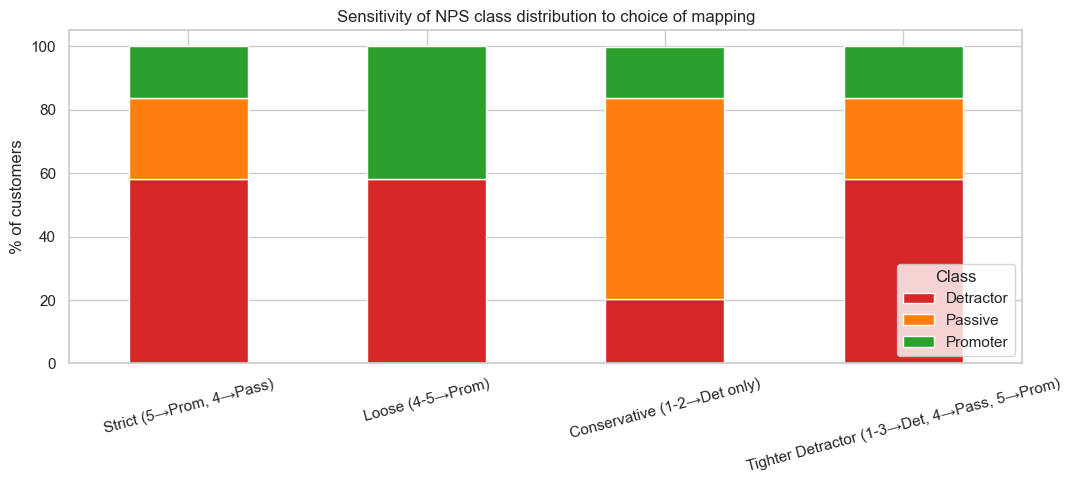

In [15]:
# Visualize sensitivity
fig, ax = plt.subplots(figsize=(11, 5))
sensitivity.T.plot(kind="bar", stacked=True, ax=ax,
                   color=[NPS_PALETTE[c] for c in NPS_CLASSES])
ax.set_ylabel("% of customers")
ax.set_title("Sensitivity of NPS class distribution to choice of mapping")
ax.legend(title="Class", loc="lower right")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_mapping_sensitivity.png")
plt.show()

## 5. Audit de fuites 

L'objectif : valider que `LEAKY_FEATURES` couvre bien tout ce qui leak, et identifier les nouveaux suspects

In [16]:
audit_df = run_leakage_audit(df)
print(f"Audit produced {len(audit_df)} rows\n")

cols_to_show = ["feature", "type", "verdict", "score",
                "pearson_r", "spearman_r", "eta_squared", "in_drop_list"]
cols_to_show = [c for c in cols_to_show if c in audit_df.columns]
print("Top 20 by association score:\n")
print(audit_df.head(20)[cols_to_show].to_string(index=False))

C:\Users\LOG\OneDrive - SUPCOM\Bureau\Challenge NPS Dr FOFANA\.venv\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\LOG\OneDrive - SUPCOM\Bureau\Challenge NPS Dr FOFANA\.venv\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\LOG\OneDrive - SUPCOM\Bureau\Challenge NPS Dr FOFANA\.venv\Lib\site-packages\pandas\core\nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


Audit produced 55 rows

Top 20 by association score:

                    feature        type     verdict  score  pearson_r  spearman_r  eta_squared  in_drop_list
                Customer ID categorical STRONG LEAK  1.000        NaN         NaN        1.000         False
                Churn Value     numeric  CONFIGURED  0.755     -0.755      -0.717          NaN          True
                  NPS_class categorical STRONG LEAK  0.720        NaN         NaN        0.720         False
            Customer Status categorical  CONFIGURED  0.571        NaN         NaN        0.571          True
                Churn Label categorical  CONFIGURED  0.569        NaN         NaN        0.569          True
                Churn Score     numeric  CONFIGURED  0.498     -0.498      -0.482          NaN          True
               Churn Reason categorical  CONFIGURED  0.431        NaN         NaN        0.431          True
             Churn Category categorical  CONFIGURED  0.426        NaN     

In [17]:
# Verdict counts
counts = audit_df["verdict"].value_counts().reindex(
    ["STRONG LEAK", "WEAK LEAK", "CONFIGURED", "CLEAN"], fill_value=0
)
print("Verdict summary:")
for v, n in counts.items():
    print(f"  {v:<14} : {n:>3} features")

Verdict summary:
  STRONG LEAK    :   2 features
  WEAK LEAK      :   0 features
  CONFIGURED     :   7 features
  CLEAN          :  46 features


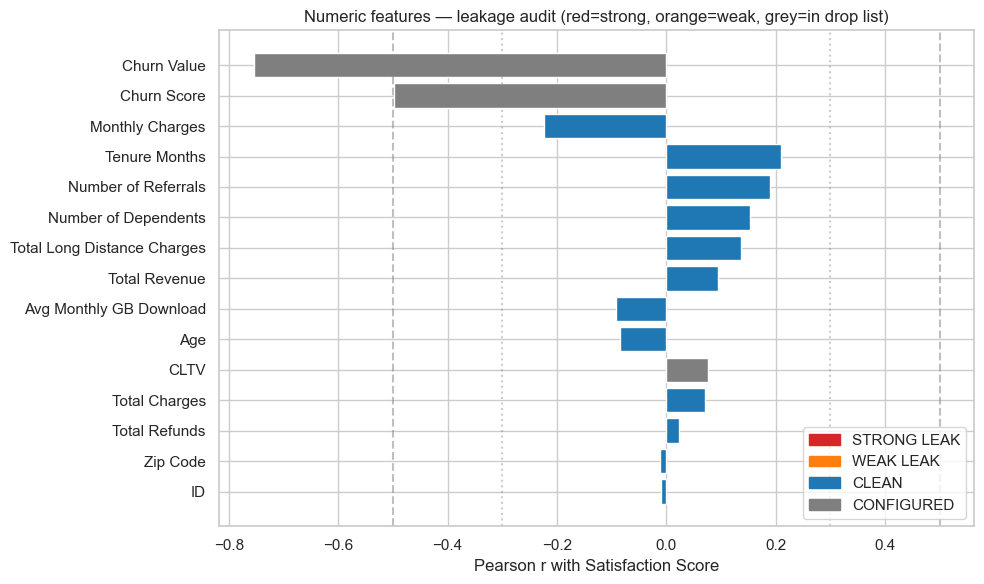

In [18]:
# Visualize: numeric features colored by verdict
numeric_audit = audit_df[audit_df["type"] == "numeric"].head(15).copy()
verdict_color = {
    "STRONG LEAK": "#d62728",
    "WEAK LEAK": "#ff7f0e",
    "CLEAN": "#1f77b4",
    "CONFIGURED": "#7f7f7f",
}
fig, ax = plt.subplots(figsize=(10, 6))
colors = [verdict_color[v] for v in numeric_audit["verdict"]]
ax.barh(numeric_audit["feature"], numeric_audit["pearson_r"], color=colors)
ax.axvline(0.5, ls="--", color="grey", alpha=0.5)
ax.axvline(-0.5, ls="--", color="grey", alpha=0.5)
ax.axvline(0.3, ls=":", color="grey", alpha=0.4)
ax.axvline(-0.3, ls=":", color="grey", alpha=0.4)
ax.set_xlabel("Pearson r with Satisfaction Score")
ax.set_title("Numeric features — leakage audit (red=strong, orange=weak, grey=in drop list)")
ax.invert_yaxis()
# Custom legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=v) for v, c in verdict_color.items()],
          loc="lower right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_leakage_numeric.png")
plt.show()

In [19]:
# Categorical leakage — focus on suspects
cat_suspects = ["Customer Status", "Churn Category", "Churn Label", "Churn Reason"]
present = [c for c in cat_suspects if c in df.columns]
print("Categorical leakage check — Satisfaction Score by category:\n")
for col in present:
    grp = df.groupby(col, observed=True)["Satisfaction Score"].agg([
        ("mean", "mean"), ("count", "count")
    ]).round(2)
    print(f"\n--- {col} ---")
    print(grp.sort_values("mean"))

Categorical leakage check — Satisfaction Score by category:


--- Customer Status ---
                 mean  count
Customer Status             
Churned          1.74   1869
Stayed           3.77   4720
Joined           3.97    454

--- Churn Category ---
                 mean  count
Churn Category              
Competitor       1.55    841
Dissatisfaction  1.71    303
Price            1.82    211
Other            2.00    200
Attitude         2.04    314

--- Churn Label ---
             mean  count
Churn Label             
Yes          1.74   1869
No           3.79   5174

--- Churn Reason ---
                                           mean  count
Churn Reason                                          
Competitor had better devices              1.09    130
Product dissatisfaction                    1.10    102
Service dissatisfaction                    1.63     89
Lack of self-service on Website            1.67     88
Long distance charges                      1.68     44
Competitor off

In [20]:
# Confirm against config
print("=" * 65)
print("LEAKY_FEATURES configured in src/config.py:")
print("=" * 65)
for f in LEAKY_FEATURES:
    in_data = f in df.columns
    if not in_data:
        print(f"  ✗  {f:<20} (not in data — fine, not all versions have it)")
        continue
    row = audit_df[audit_df["feature"] == f]
    if not row.empty:
        score = row["score"].values[0]
        verdict = row["verdict"].values[0]
        flag = "✓" if score >= 0.3 else "⚠"
        print(f"  {flag}  {f:<20} score={score:>5.3f}  ({verdict})")
    else:
        print(f"  ?  {f:<20} (in data but not audited — check audit logic)")

LEAKY_FEATURES configured in src/config.py:
  ?  Satisfaction Score   (in data but not audited — check audit logic)
  ✓  Churn Score          score=0.498  (CONFIGURED)
  ✓  Churn Value          score=0.755  (CONFIGURED)
  ✓  Churn Label          score=0.569  (CONFIGURED)
  ✓  Churn Reason         score=0.431  (CONFIGURED)
  ✓  Churn Category       score=0.426  (CONFIGURED)
  ✓  Customer Status      score=0.571  (CONFIGURED)
  ⚠  CLTV                 score=0.076  (CONFIGURED)


## 6. Features numériques par classe NPS

On regarde quelles features candidates discriminent visuellement les classes.

Plotting 10 numeric features by NPS class


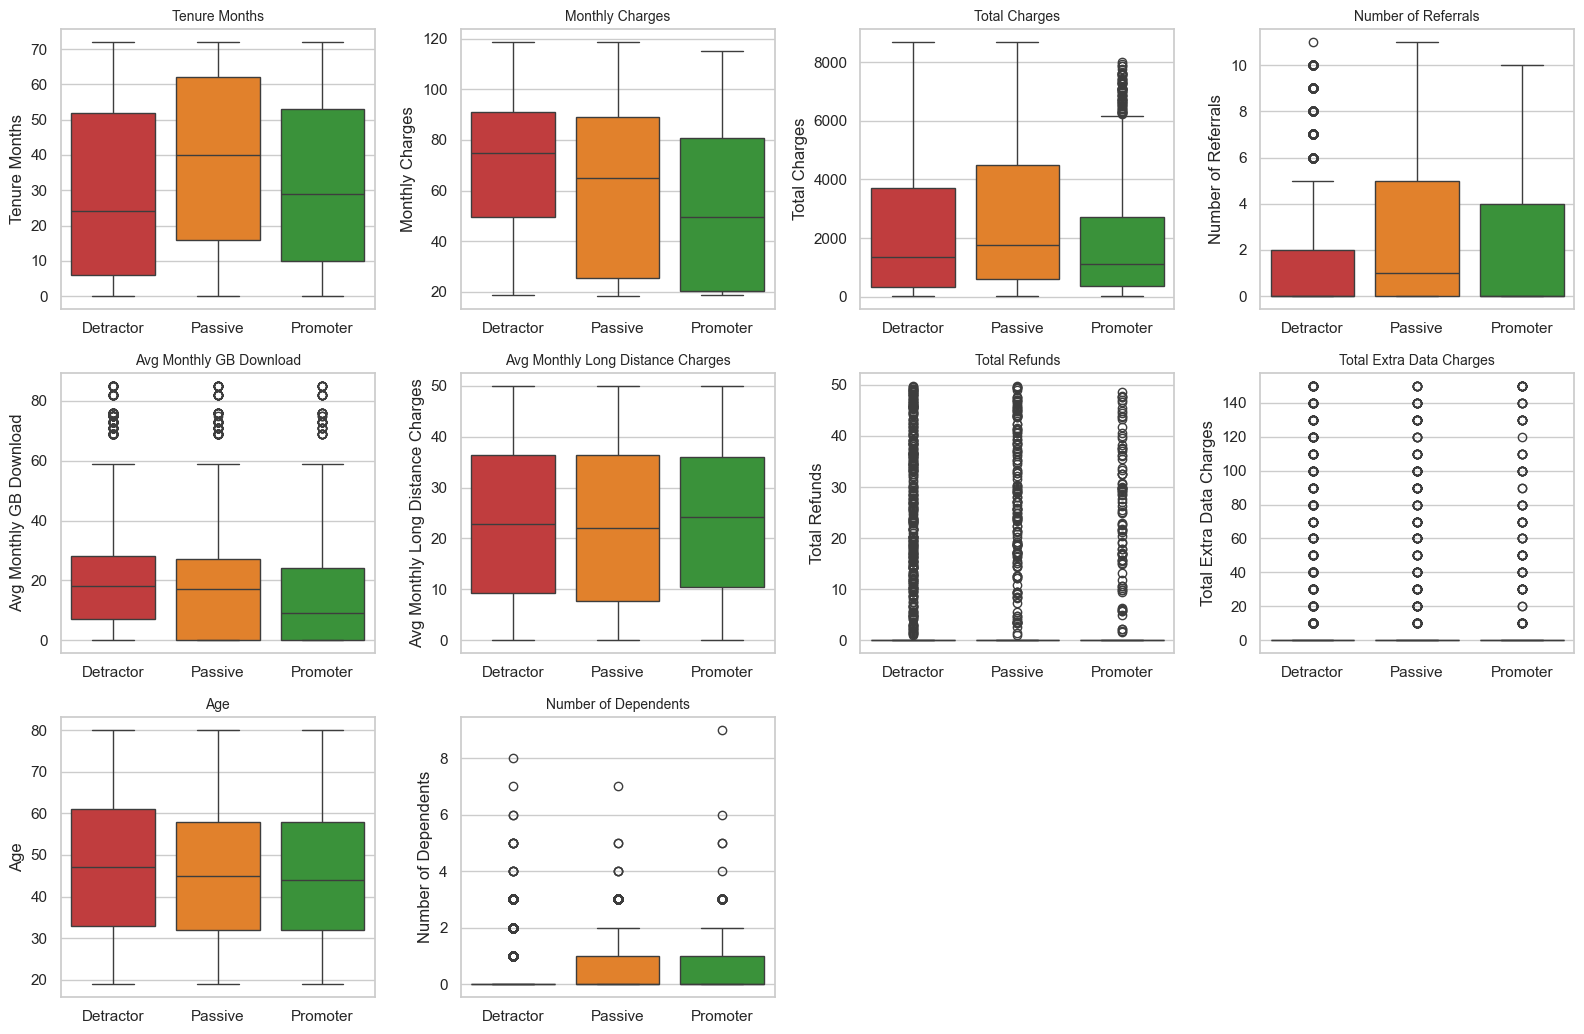

In [21]:
numeric_candidates = [
    "Tenure Months", "Monthly Charges", "Total Charges",
    "Number of Referrals", "Avg Monthly GB Download",
    "Avg Monthly Long Distance Charges",
    "Total Refunds", "Total Extra Data Charges",
    "Age", "Number of Dependents",
]
present = [c for c in numeric_candidates if c in df.columns]
print(f"Plotting {len(present)} numeric features by NPS class")

n = len(present)
ncols = 4
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows))
axes = np.array(axes).flatten()
for ax, col in zip(axes, present):
    sns.boxplot(data=df, x="NPS_class", y=col, hue="NPS_class", ax=ax,
                palette=NPS_PALETTE, order=NPS_CLASSES, legend=False)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
for ax in axes[len(present):]:
    ax.axis("off")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_numeric_by_nps.png")
plt.show()

## 7. Features catégorielles par classe NPS

Plotting 8 categorical features by NPS class


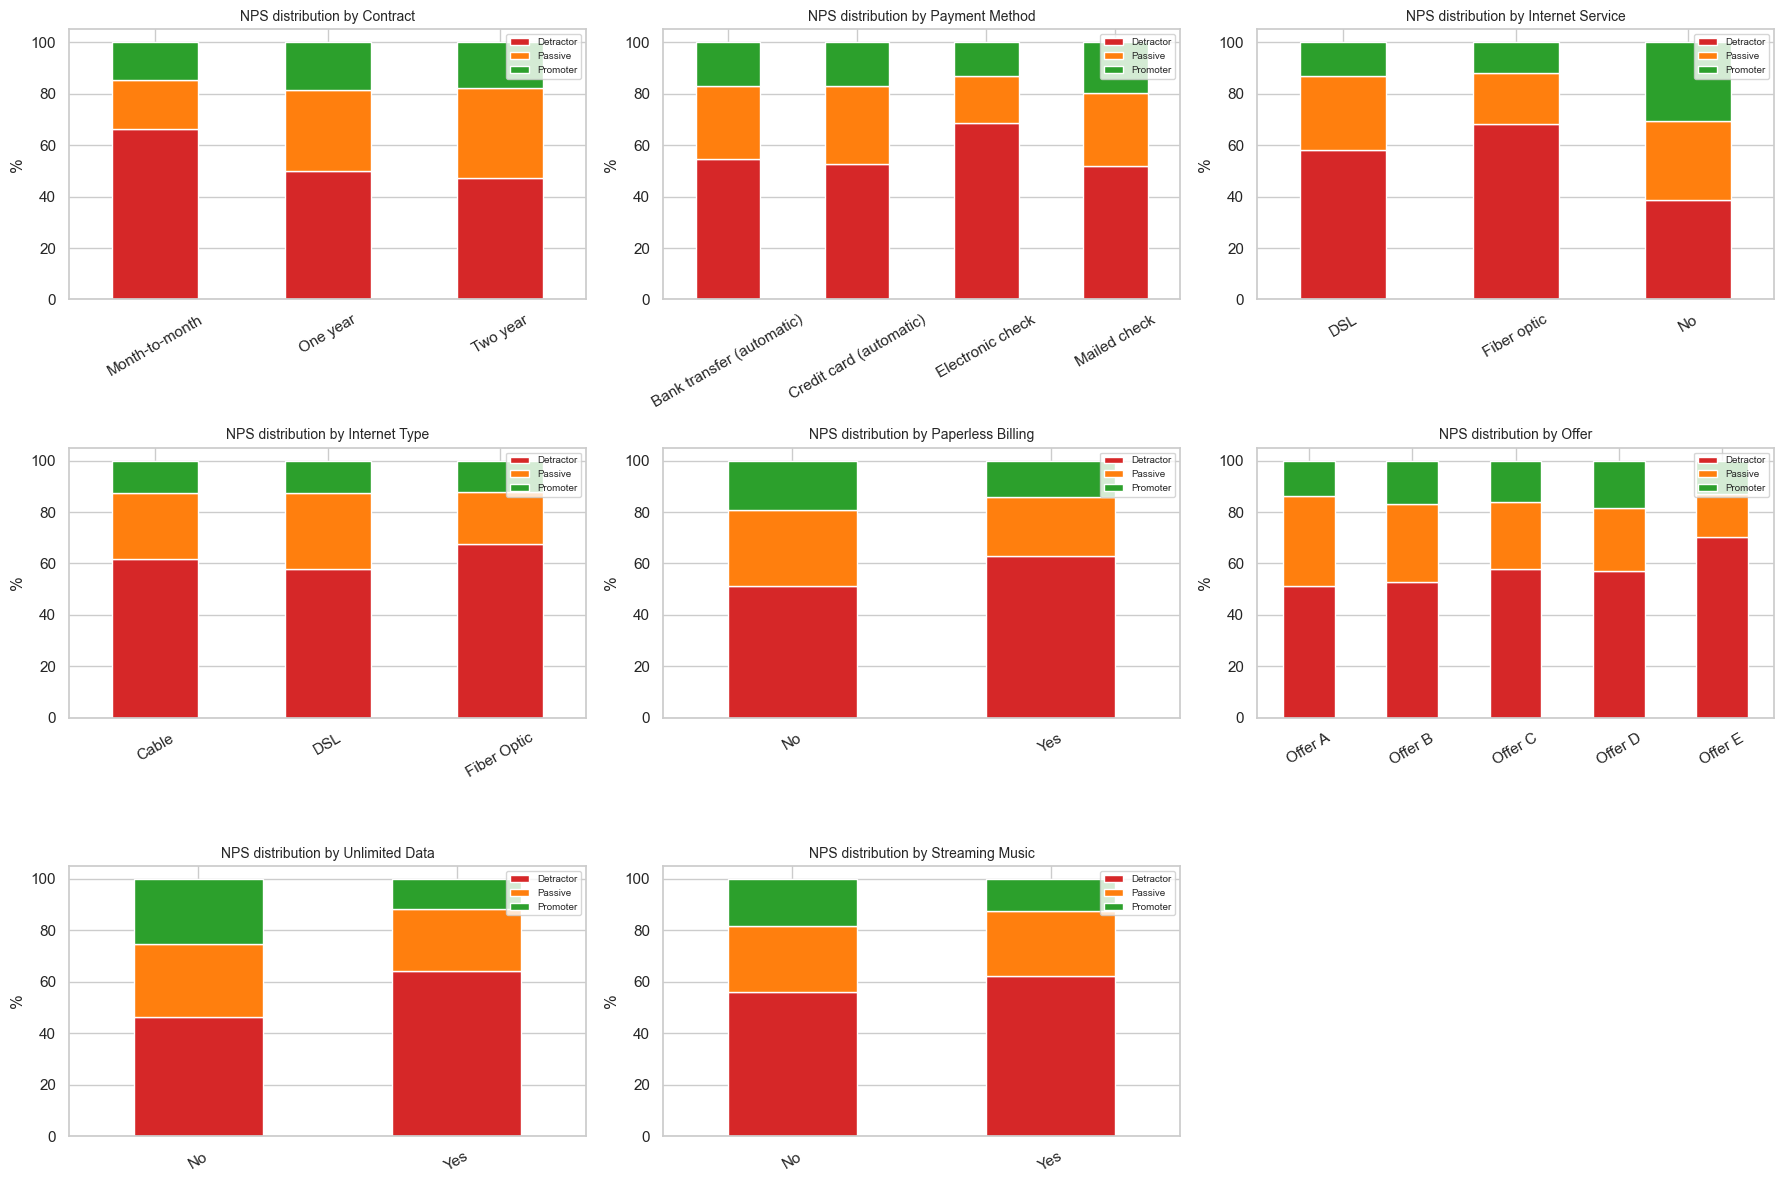

In [22]:
cat_candidates = [
    "Contract", "Payment Method", "Internet Service", "Internet Type",
    "Paperless Billing", "Offer", "Unlimited Data", "Streaming Music",
]
present = [c for c in cat_candidates if c in df.columns]
print(f"Plotting {len(present)} categorical features by NPS class")

n = len(present)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
axes = np.array(axes).flatten()
for ax, col in zip(axes, present):
    ct = pd.crosstab(df[col], df["NPS_class"], normalize="index") * 100
    if not ct.empty:
        ct = ct.reindex(columns=NPS_CLASSES, fill_value=0)
        ct.plot(kind="bar", stacked=True, ax=ax,
                color=[NPS_PALETTE[c] for c in NPS_CLASSES])
        ax.set_title(f"NPS distribution by {col}", fontsize=10)
        ax.set_ylabel("%")
        ax.set_xlabel("")
        ax.legend(loc="upper right", fontsize=7)
        ax.tick_params(axis="x", rotation=30)
for ax in axes[len(present):]:
    ax.axis("off")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_categorical_by_nps.png")
plt.show()

## 8. Focus — features riches de la v11.1.3

Trois features potentiellement très prédictives qui n'existent pas dans la version basique.

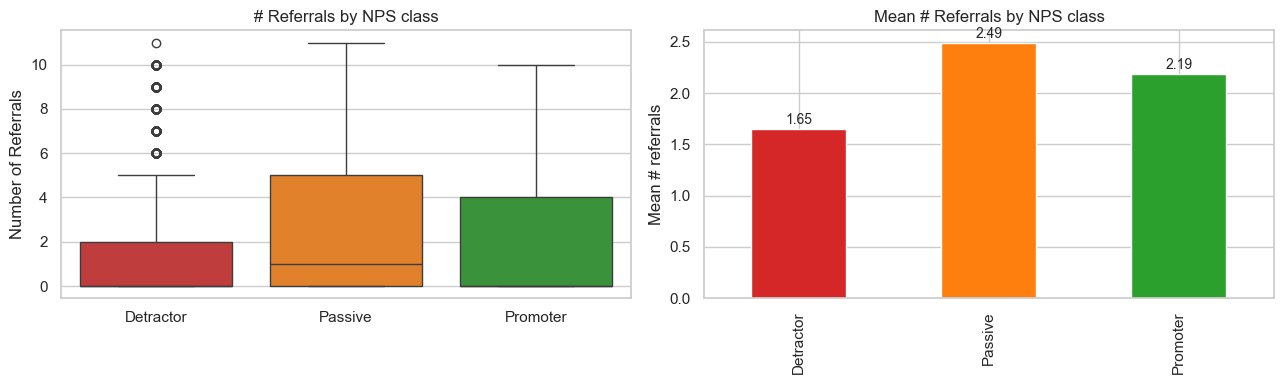

In [23]:
# Number of Referrals: strongest loyalty signal
if "Number of Referrals" in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    sns.boxplot(data=df, x="NPS_class", y="Number of Referrals",
                hue="NPS_class", ax=axes[0],
                palette=NPS_PALETTE, order=NPS_CLASSES, legend=False)
    axes[0].set_title("# Referrals by NPS class")
    axes[0].set_xlabel("")
    
    grp = df.groupby("NPS_class", observed=True)["Number of Referrals"].mean().reindex(NPS_CLASSES)
    grp.plot(kind="bar", ax=axes[1],
             color=[NPS_PALETTE[c] for c in NPS_CLASSES])
    axes[1].set_title("Mean # Referrals by NPS class")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("Mean # referrals")
    for i, v in enumerate(grp.values):
        axes[1].text(i, v + 0.05, f"{v:.2f}", ha="center", fontsize=10)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "08_referrals.png")
    plt.show()

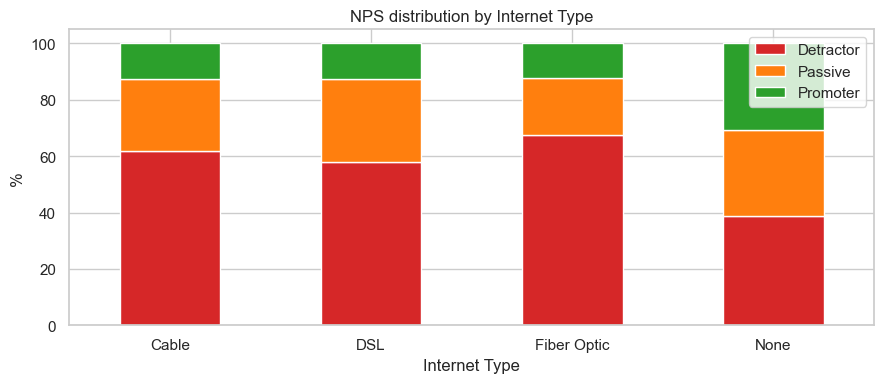

In [24]:
# Internet Type: Fiber vs DSL is often a major churn/NPS driver
if "Internet Type" in df.columns:
    fig, ax = plt.subplots(figsize=(9, 4))
    ct = pd.crosstab(df["Internet Type"].fillna("None"), df["NPS_class"], normalize="index") * 100
    ct = ct.reindex(columns=NPS_CLASSES, fill_value=0)
    ct.plot(kind="bar", stacked=True, ax=ax,
            color=[NPS_PALETTE[c] for c in NPS_CLASSES])
    ax.set_title("NPS distribution by Internet Type")
    ax.set_ylabel("%")
    ax.legend(loc="upper right")
    ax.tick_params(axis="x", rotation=0)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "09_internet_type.png")
    plt.show()

Offer distribution: {nan: 3877, 'Offer B': 824, 'Offer E': 805, 'Offer D': 602, 'Offer A': 520, 'Offer C': 415}



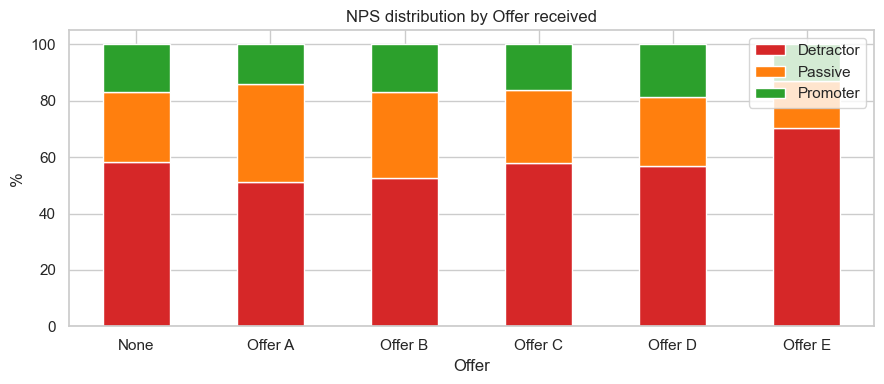

In [25]:
# Offer: marketing offer received
if "Offer" in df.columns:
    print(f"Offer distribution: {df['Offer'].value_counts(dropna=False).to_dict()}\n")
    fig, ax = plt.subplots(figsize=(9, 4))
    ct = pd.crosstab(df["Offer"].fillna("None"), df["NPS_class"], normalize="index") * 100
    ct = ct.reindex(columns=NPS_CLASSES, fill_value=0)
    ct.plot(kind="bar", stacked=True, ax=ax,
            color=[NPS_PALETTE[c] for c in NPS_CLASSES])
    ax.set_title("NPS distribution by Offer received")
    ax.set_ylabel("%")
    ax.legend(loc="upper right")
    ax.tick_params(axis="x", rotation=0)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "10_offer.png")
    plt.show()

## 9. Géographie

Toutes les données sont en Californie. La granularité ZIP (~1600 distincts) est trop fine pour modéliser directement → on utilisera plutôt :
- la **Population** (par ZIP) déjà fournie
- des clusters lat/long si nécessaire

In [26]:
geo_cols = [c for c in ["Zip Code", "City", "Latitude", "Longitude", "Population"] if c in df.columns]
print("Geographic columns:", geo_cols)
print()
if "Zip Code" in df.columns:
    print(f"Distinct ZIPs: {df['Zip Code'].nunique():,}")
if "City" in df.columns:
    print(f"Distinct cities: {df['City'].nunique():,}")
if "Latitude" in df.columns:
    print(f"Lat range: {df['Latitude'].min():.2f} → {df['Latitude'].max():.2f}")
if "Longitude" in df.columns:
    print(f"Lng range: {df['Longitude'].min():.2f} → {df['Longitude'].max():.2f}")
if "Population" in df.columns:
    print(f"Population per ZIP: median {df['Population'].median():,.0f}, max {df['Population'].max():,.0f}")

Geographic columns: ['Zip Code', 'City', 'Latitude', 'Longitude', 'Population']

Distinct ZIPs: 1,652
Distinct cities: 1,129
Lat range: 32.56 → 41.96
Lng range: -124.30 → -114.19
Population per ZIP: median 15,975, max 105,285


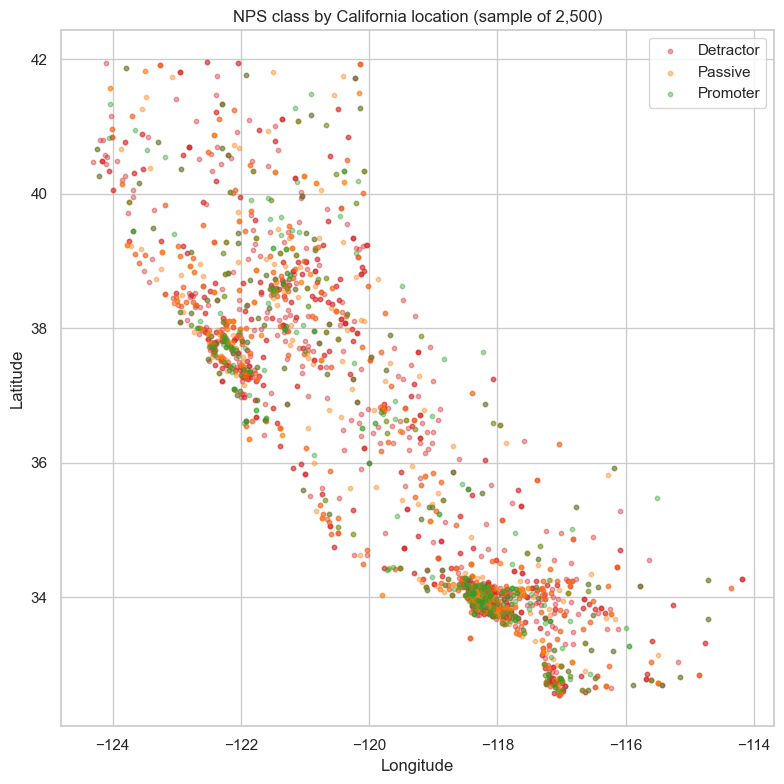

In [27]:
# Map of NPS by location
if {"Latitude", "Longitude"}.issubset(df.columns):
    sample = df.sample(min(2500, len(df)), random_state=42)
    fig, ax = plt.subplots(figsize=(8, 8))
    for cls in NPS_CLASSES:
        sub = sample[sample["NPS_class"] == cls]
        ax.scatter(sub["Longitude"], sub["Latitude"],
                   c=NPS_PALETTE[cls], label=cls, alpha=0.4, s=10)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title("NPS class by California location (sample of 2,500)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "11_geographic.png")
    plt.show()

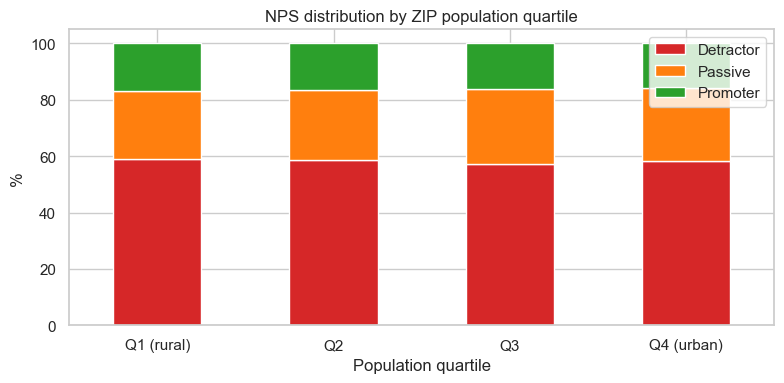

In [28]:
# NPS by population density bucket (urban vs rural proxy)
if "Population" in df.columns:
    df["Pop_bucket"] = pd.qcut(df["Population"], q=4,
                                labels=["Q1 (rural)", "Q2", "Q3", "Q4 (urban)"],
                                duplicates="drop")
    fig, ax = plt.subplots(figsize=(8, 4))
    ct = pd.crosstab(df["Pop_bucket"], df["NPS_class"], normalize="index") * 100
    ct = ct.reindex(columns=NPS_CLASSES, fill_value=0)
    ct.plot(kind="bar", stacked=True, ax=ax,
            color=[NPS_PALETTE[c] for c in NPS_CLASSES])
    ax.set_title("NPS distribution by ZIP population quartile")
    ax.set_ylabel("%")
    ax.set_xlabel("Population quartile")
    ax.legend(loc="upper right")
    ax.tick_params(axis="x", rotation=0)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "12_population_density.png")
    plt.show()

## 10. Démographie × NPS — preview fairness

Premier signal : NPS varie-t-il par sous-groupe démographique ? Sera repris en détail en Phase 11.

Plotting NPS by 6 demographic features


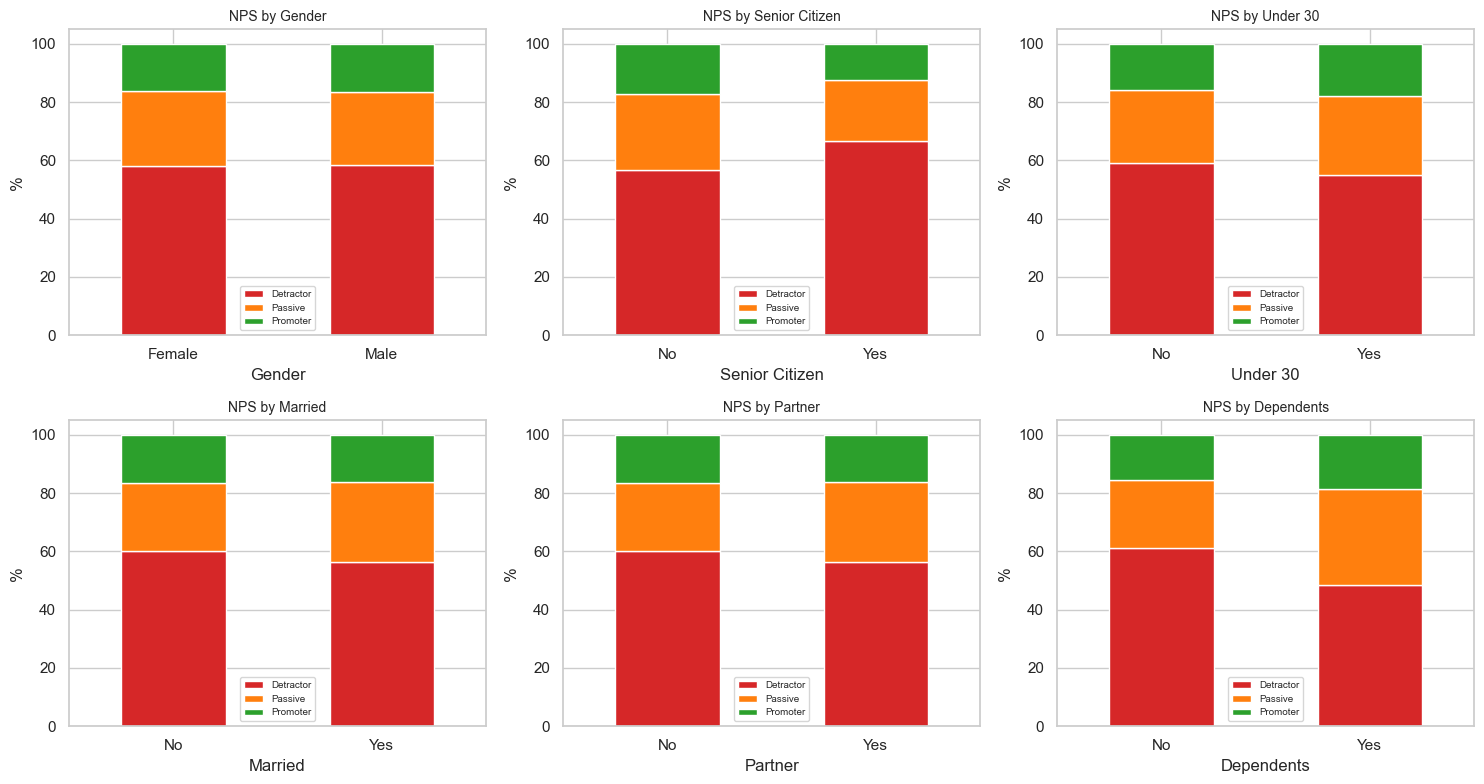

In [29]:
demo_features = [c for c in ["Gender", "Senior Citizen", "Under 30",
                              "Married", "Partner", "Dependents"]
                if c in df.columns]
print(f"Plotting NPS by {len(demo_features)} demographic features")

n = len(demo_features)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = np.array(axes).flatten()
for ax, col in zip(axes, demo_features):
    ct = pd.crosstab(df[col], df["NPS_class"], normalize="index") * 100
    ct = ct.reindex(columns=NPS_CLASSES, fill_value=0)
    ct.plot(kind="bar", stacked=True, ax=ax,
            color=[NPS_PALETTE[c] for c in NPS_CLASSES])
    ax.set_title(f"NPS by {col}", fontsize=10)
    ax.set_ylabel("%")
    ax.legend(fontsize=7)
    ax.tick_params(axis="x", rotation=0)
for ax in axes[len(demo_features):]:
    ax.axis("off")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "13_demographics.png")
plt.show()

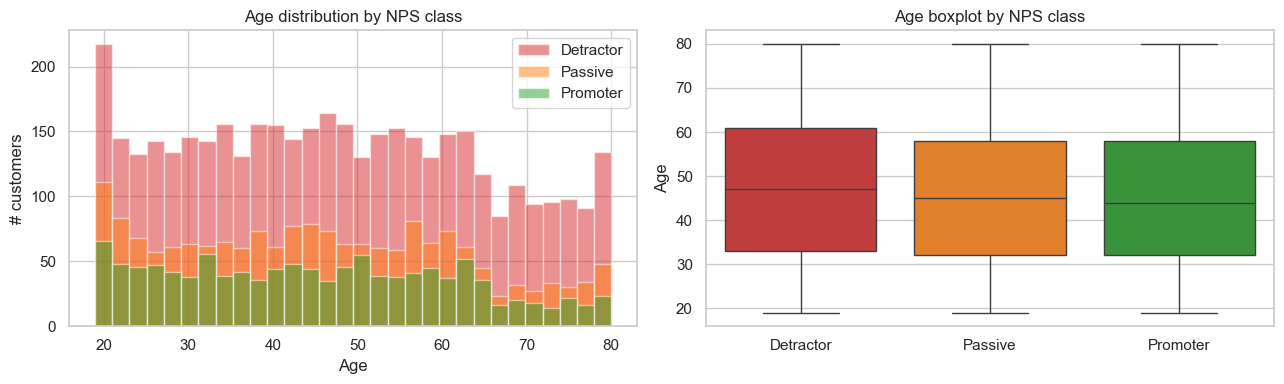

In [30]:
# Age (continuous) is special — show its distribution by NPS class
if "Age" in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for cls in NPS_CLASSES:
        sub = df[df["NPS_class"] == cls]["Age"].dropna()
        axes[0].hist(sub, bins=30, alpha=0.5, label=cls, color=NPS_PALETTE[cls])
    axes[0].set_xlabel("Age")
    axes[0].set_ylabel("# customers")
    axes[0].set_title("Age distribution by NPS class")
    axes[0].legend()
    
    sns.boxplot(data=df, x="NPS_class", y="Age", hue="NPS_class", ax=axes[1],
                palette=NPS_PALETTE, order=NPS_CLASSES, legend=False)
    axes[1].set_title("Age boxplot by NPS class")
    axes[1].set_xlabel("")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "14_age.png")
    plt.show()

## 11. Sauvegarde du dataset enrichi

In [31]:
out = DATA_INTERIM / "telco_with_nps.parquet"
df.to_parquet(out, index=False)
print(f"Saved {len(df):,} rows × {len(df.columns)} columns to {out}")

Saved 7,043 rows × 57 columns to C:\Users\LOG\OneDrive - SUPCOM\Bureau\Challenge NPS Dr FOFANA\nps-prediction\data\interim\telco_with_nps.parquet


## 12. Synthèse — chiffres réels de l'EDA

### Volume & structure
- **7 043 clients × 55 colonnes** après merge des 6 fichiers IBM Cognos
  (33 base + 13 services + 3 status + 4 démographie + 2 location + 2 population)
- 0 doublon sur `Customer ID`
- 4 colonnes constantes à drop : `Count` (=1), `Country` (US), `State` (Californie), `Quarter` (Q3)
- Missing values concentrés sur 5 colonnes :
  - `Churn Reason` / `Churn Category` : 73 % NaN (attendu — uniquement les churners)
  - `Offer` : 55 % NaN (pas d'offre marketing reçue)
  - `Internet Type` : 22 % NaN (clients sans internet)
  - `Total Charges` : 0,16 % NaN (11 nouveaux clients à imputer)

### Distribution de la cible (baseline mapping Sat 1-3 → D, 4 → P, 5 → Pr)
- **Detractor : 58,3 %** (4 105) / **Passive : 25,4 %** (1 789) / **Promoter : 16,3 %** (1 149)
- **NPS index : −42** — base hautement détractrice, atypique mais cohérente
- Distribution Satisfaction Score sous-jacente : pic à 3 (37,8 %) puis 4 (25,4 %), médiane = 3
- **Implication modélisation** : déséquilibre sévère, mais inversé par rapport à la moyenne télécom
  (où les Promoters dominent).

### Sensibilité du mapping
| Mapping | Detractor | Passive | Promoter |
|---|---|---|---|
| Strict (5→Pr, 4→Pa) — baseline | 58,3 | 25,4 | 16,3 |
| Loose (4-5→Pr) | 58,3 | — | 41,7 |
| Conservative (1-2→Det only) | 20,4 | 63,2 | 16,3 |

→ Le mapping baseline est **médian** entre les extrêmes, justifiable. À documenter en Phase 2.

### Audit de fuites — verdicts confirmés

| Verdict | Count | Features |
|---|---|---|
| STRONG LEAK | 2 | `Customer ID`, `NPS_class` — **artefacts** (cf. note) |
| WEAK LEAK | 0 | — |
| CONFIGURED | 7 | `Churn Value` (0,755), `Customer Status` (0,571), `Churn Label` (0,569), `Churn Score` (0,498), `Churn Reason` (0,431), `Churn Category` (0,426), `CLTV` (0,076) |
| CLEAN | 46 | features candidates |

**Top 7 features CLEAN par association** :
| Feature | \|r\| | Interprétation |
|---|---|---|
| `Monthly Charges` | 0,224 | Plus on paie, plus on est détracteur |
| `Tenure Months` | 0,210 | Plus on reste, plus on est promoteur |
| `Number of Referrals` | 0,189 | Loyalty signal (cf. focus §8) |
| `Number of Dependents` | 0,153 | Foyer à charge → moins promoteur |
| `Total Long Distance Charges` | 0,137 | Usage premium |
| `Total Revenue` | 0,095 | **Pas un leaker** — confirmé sum des charges passées |
| `Avg Monthly GB Download` | 0,092 | Usage internet |

**Décision défendable sur `CLTV`** : score d'association = 0,076 → très faible. Techniquement
non-leaker statistiquement. À retenir : on garde le drop **par précaution temporelle** (CLTV
peut être recalculé post-hoc et inclure des comportements futurs), mais on pourra justifier
de le réactiver en Phase 4 si le besoin de signal se fait sentir.

### Insights features (validés visuellement)
- **`Number of Referrals`** : confirmé signal de loyauté très net — Promoters référent
  significativement plus que Detractors. Feature à conserver et exploiter en Phase 4.
- **`Customer Status`** : Stayed (Sat=3,77), Joined (Sat=3,97), Churned (Sat=1,74) — montre
  bien que c'est un leaker direct, **drop confirmé**.
- **`Churn Reason`** : top motifs corrélés à insatisfaction = "Competitor had better devices" (1,09),
  "Product dissatisfaction" (1,10), "Service dissatisfaction" (1,63) → utile en Phase 10
  pour SHAP qualitatif, mais **drop en feature**.
- **`Internet Type Fiber`** : visible sur la figure 9 — sur-représentation des Detractors
  (probable tension qualité/pricing fibre).
- **`Offer`** : 55 % ne reçoivent rien ; les bénéficiaires d'offres montrent des distributions
  NPS différentes — feature utile pour Phase 4 et mesure ROI marketing.

### Géographie
- 100 % Californie (Latitude 32,6 → 42,0 ; Longitude -124,3 → -114,2)
- **1 652 ZIPs distincts** / **1 129 cities** → granularité trop fine pour modélisation directe
- `Population` par ZIP joinable avec succès (médiane 15 975, max 105 285)
- Carte (figure 11) : pas de pattern géographique évident → la géo seule n'est pas
  prédictive ; elle servira surtout en proxy urbain/rural via `Population`

### Premier signal fairness
- Léger écart NPS observé entre `Senior Citizen` Yes/No (à chiffrer précisément en Phase 11)
- Pas d'écart visible par `Gender`
- `Married` et `Number of Dependents` semblent montrer des patterns qui méritent un audit

### ⚠ Note méthodologique sur l'audit

L'audit a flagué `Customer ID` (score 1,000) et `NPS_class` (0,720) en STRONG LEAK.
Ce sont des **artefacts** :
- `Customer ID` : 7 043 catégories uniques → eta² = 1 mécaniquement, pas un vrai signal
- `NPS_class` : c'est notre **cible dérivée elle-même**, créée pendant le notebook

Aucun de ces deux n'est un "vrai" leaker à ajouter à `LEAKY_FEATURES` — ils ne seront
pas dans la matrice de features de toute façon. À mentionner dans le rapport pour
expliquer la lecture de la table.

### Fichier produit
`data/interim/telco_with_nps.parquet` — **7 043 × 57 colonnes** (55 d'origine + `NPS_class` + `Pop_bucket`)

### Prochaine étape — Phase 2

Construction du dataset modélisable :
1. Drop systématique des `LEAKY_FEATURES` + `Customer ID` + colonnes constantes
2. Drop des colonnes auxiliaires créées dans le notebook (`Pop_bucket`, garder `NPS_class` comme cible)
3. Imputation propre des 11 `Total Charges` manquants
4. Encodage de `Internet Type` NaN → "None" (cohérent avec absence d'Internet Service)
5. Choix de stratégie de split simulant le gap respondants/silencieux
6. Sauvegarde finale dans `data/processed/dataset.parquet`